## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [34]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [35]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [36]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2022_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2022.csv', encoding=enc)

In [37]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-01,2022,1,2021-12-31,37.991999,23.654887,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,2022-01-01,37.991999,23.654887,14226.0,14165.0,37.991999,23.654887,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,2022-01-01,37.950174,23.650108,0.130592,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.130592,0.130592
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-16,2022,1,2022-01-15,37.991999,23.654887,0.096758,0.002547,-0.134993,-0.002547,0.187609,0.061188,-0.196106,-0.061188,0.118994,0.064595,0.091346,0.064595,2022-01-16,37.991999,23.654887,14287.0,13866.0,37.991999,23.654887,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,2022-01-16,37.950174,23.650108,159.481701,2022-01-09,2022-01-02,2022-01-09,2022-01-02,78.943867,159.351109
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-01,2022,1,2021-12-31,38.009965,23.825567,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,2022-01-01,38.009965,23.825567,14321.0,14100.0,38.009965,23.825567,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,2022-01-01,38.050174,23.850109,0.062748,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.062748,0.062748
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-16,2022,1,2022-01-15,38.009965,23.825567,0.147814,0.072285,-0.136770,-0.072285,0.161369,0.079583,-0.143985,-0.079583,0.016419,0.017736,0.010888,0.017736,2022-01-16,38.009965,23.825567,14018.0,13834.0,38.009965,23.825567,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,2022-01-16,38.050174,23.850109,79.632325,2022-01-09,2022-01-02,2022-01-09,2022-01-02,46.362894,79.569577
4,αγιου δημητριου,αττικης,23.73031,37.93357,2022-01-01,2022,1,2021-12-31,37.933609,23.731244,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,2022-01-01,37.933609,23.731244,14206.0,14139.0,37.933609,23.731244,14200.181818,13948.187500,14414.100,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,2022-01-01,37.950174,23.750109,0.160617,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.160617,0.160617


In [38]:
wnv_file.head()

,lau1,nuts2,dt_placement,case


In [39]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [40]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [41]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [42]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-01,2022,1,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.0,14165.0,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-16,2022,1,0.096758,0.002547,-0.134993,-0.002547,0.187609,0.061188,-0.196106,-0.061188,0.118994,0.064595,0.091346,0.064595,14287.0,13866.0,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,159.481701,78.943867,159.351109
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-01,2022,1,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.0,14100.0,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-16,2022,1,0.147814,0.072285,-0.136770,-0.072285,0.161369,0.079583,-0.143985,-0.079583,0.016419,0.017736,0.010888,0.017736,14018.0,13834.0,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,79.632325,46.362894,79.569577
4,αγιου δημητριου,αττικης,23.73031,37.93357,2022-01-01,2022,1,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.0,14139.0,14200.181818,13948.187500,14414.100,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617


In [43]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case


In [44]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


[]

Length: 0


In [45]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [46]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-01,2022,1,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.0,14165.0,14199.125000,13934.842105,14363.375000,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592,NaN
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-16,2022,1,0.096758,0.002547,-0.134993,-0.002547,0.187609,0.061188,-0.196106,-0.061188,0.118994,0.064595,0.091346,0.064595,14287.0,13866.0,14199.125000,13934.842105,14363.375000,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,159.481701,78.943867,159.351109,NaN
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-01,2022,1,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.0,14100.0,14099.818182,13918.117647,14384.600000,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748,NaN
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-16,2022,1,0.147814,0.072285,-0.136770,-0.072285,0.161369,0.079583,-0.143985,-0.079583,0.016419,0.017736,0.010888,0.017736,14018.0,13834.0,14099.818182,13918.117647,14384.600000,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,79.632325,46.362894,79.569577,NaN
4,αγιου δημητριου,αττικης,23.73031,37.93357,2022-01-01,2022,1,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.0,14139.0,14200.181818,13948.187500,14414.100000,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3643,ωρωπου,αττικης,23.87203,38.23148,2022-12-16,2022,12,0.291381,0.094023,-0.241657,-0.094023,0.316639,0.121830,-0.245972,-0.121830,0.043571,0.036107,0.043410,0.036107,14347.0,13920.0,14124.307692,13790.428571,14276.181818,13818.444444,14253.700000,13753.000000,14812.400000,14098.125000,1013.245119,34.230381,36.132126,NaN
3644,ωρωπου,αττικης,23.89487,38.26741,2022-12-01,2022,12,0.200727,0.390116,-0.013804,-0.390116,0.158974,0.307059,-0.016557,-0.307059,0.052324,0.085045,0.017491,0.085045,14348.0,14021.0,14048.714286,13842.333333,14217.076923,13904.416667,14296.000000,13805.100000,14727.285714,14172.875000,977.112993,126.262493,169.060118,NaN
3645,ωρωπου,αττικης,23.89487,38.26741,2022-12-16,2022,12,0.331144,0.325549,-0.207146,-0.325549,0.412207,0.287915,-0.304568,-0.287915,0.044920,0.056979,0.053888,0.056979,14293.0,14173.0,14048.714286,13842.333333,14217.076923,13904.416667,14296.000000,13805.100000,14727.285714,14172.875000,1013.245119,34.230381,36.132126,NaN
3646,ωρωπου,αττικης,23.66640,38.24944,2022-12-01,2022,12,0.218310,0.117330,-0.097252,-0.117330,0.277010,0.162422,-0.170448,-0.162422,0.050395,0.046369,0.069366,0.046369,14327.0,14001.0,14068.230769,13841.200000,14224.933333,13906.300000,14383.428571,13802.500000,14802.238095,14206.812500,819.627359,82.614980,111.766709,NaN


In [47]:
merged = fillna(merged,{'case': 0})

In [48]:
merged['case'].value_counts()

0    3648
Name: case, dtype: int64

In [49]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [50]:
dataset = grouped.mean()

In [51]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2022-01-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2022.0,1.0,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.000000,14165.000000,14199.125000,13934.842105,14363.375000,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592,0.0
1,2022-01-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2022.0,1.0,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.000000,14100.000000,14099.818182,13918.117647,14384.600000,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748,0.0
2,2022-01-01,αγιου δημητριου,αττικης,23.730310,37.933570,2022.0,1.0,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.000000,14139.000000,14200.181818,13948.187500,14414.100000,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617,0.0
3,2022-01-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2022.0,1.0,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,14199.000000,14119.000000,14190.625000,13901.705882,14401.750000,13960.200000,14454.111111,13833.666667,15002.235294,14317.058824,0.170459,0.170459,0.170459,0.0
4,2022-01-01,αγκιστριου,αττικης,23.340090,37.695030,2022.0,1.0,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14439.000000,14284.000000,14257.210526,14079.428571,14341.461538,14109.933333,14310.692308,14083.846154,14608.150000,14369.600000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,2022-12-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2022.0,12.0,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,14388.000000,14246.000000,14126.733333,13924.937500,14387.636364,13976.357143,14458.777778,13907.812500,14918.823529,14314.857143,878.533587,64.381842,66.835793,0.0
1580,2022-12-16,φυλης,αττικης,23.688620,38.106703,2022.0,12.0,0.216847,0.110849,-0.152700,-0.110849,0.226193,0.088282,-0.180252,-0.088282,0.052931,0.038263,0.061033,0.038263,14316.666667,13979.000000,14073.853817,13832.119048,14245.753302,13860.322611,14232.629759,13766.500000,14818.647475,14186.453276,829.531002,37.073307,38.705631,0.0
1581,2022-12-16,χαλανδριου,αττικης,23.809410,38.022260,2022.0,12.0,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,14403.000000,14164.000000,14091.900000,13949.066667,14388.250000,13990.642857,14367.100000,13856.142857,14917.647059,14351.625000,930.487912,72.550454,75.314096,0.0
1582,2022-12-16,χαϊδαριου,αττικης,23.630840,38.009420,2022.0,12.0,0.320253,0.268085,-0.157603,-0.268085,0.343233,0.240475,-0.205532,-0.240475,0.048015,0.063077,0.058487,0.063077,14339.000000,14122.000000,14190.052632,13901.263158,14320.923077,13998.000000,14417.083333,13866.933333,14846.409091,14306.055556,839.945864,58.605859,61.133574,0.0


In [52]:
dataset = dataset.astype({'case': 'int'})

In [53]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [54]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [55]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [56]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [57]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2022-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022,1,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.000000,14165.000000,14199.125000,13934.842105,14363.375000,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592,0,1,52,44.75555,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
1,2022-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2022,1,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.000000,14100.000000,14099.818182,13918.117647,14384.600000,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748,0,1,52,44.85879,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
2,2022-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2022,1,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.000000,14139.000000,14200.181818,13948.187500,14414.100000,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617,0,1,52,44.74465,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
3,2022-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2022,1,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,14199.000000,14119.000000,14190.625000,13901.705882,14401.750000,13960.200000,14454.111111,13833.666667,15002.235294,14317.058824,0.170459,0.170459,0.170459,0,1,52,44.83209,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
4,2022-01-01,αγκιστριου,αττικης,23.34009,37.69503,2022,1,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14439.000000,14284.000000,14257.210526,14079.428571,14341.461538,14109.933333,14310.692308,14083.846154,14608.150000,14369.600000,0.000000,0.000000,0.000000,0,1,52,44.33593,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,2022-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2022,12,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,14388.000000,14246.000000,14126.733333,13924.937500,14387.636364,13976.357143,14458.777778,13907.812500,14918.823529,14314.857143,878.533587,64.381842,66.835793,0,16,50,44.83787,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420
1580,2022-12-16,φυλης,αττικης,23.68862,38.10670,2022,12,0.216847,0.110849,-0.152700,-0.110849,0.226193,0.088282,-0.180252,-0.088282,0.052931,0.038263,0.061033,0.038263,14316.666667,13979.000000,14073.853817,13832.119048,14245.753302,13860.322611,14232.629759,13766.500000,14818.647475,14186.453276,829.531002,37.073307,38.705631,0,16,50,44.86949,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420
1581,2022-12-16,χαλανδριου,αττικης,23.80941,38.02226,2022,12,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,14403.000000,14164.000000,14091.900000,13949.066667,14388.250000,13990.642857,14367.100000,13856.142857,14917.647059,14351.625000,930.487912,72.550454,75.314096,0,16,50,44.86179,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420
1582,2022-12-16,χαϊδαριου,αττικης,23.63084,38.00942,2022,12,0.320253,0.268085,-0.157603,-0.268085,0.343233,0.240475,-0.2

<AxesSubplot:>

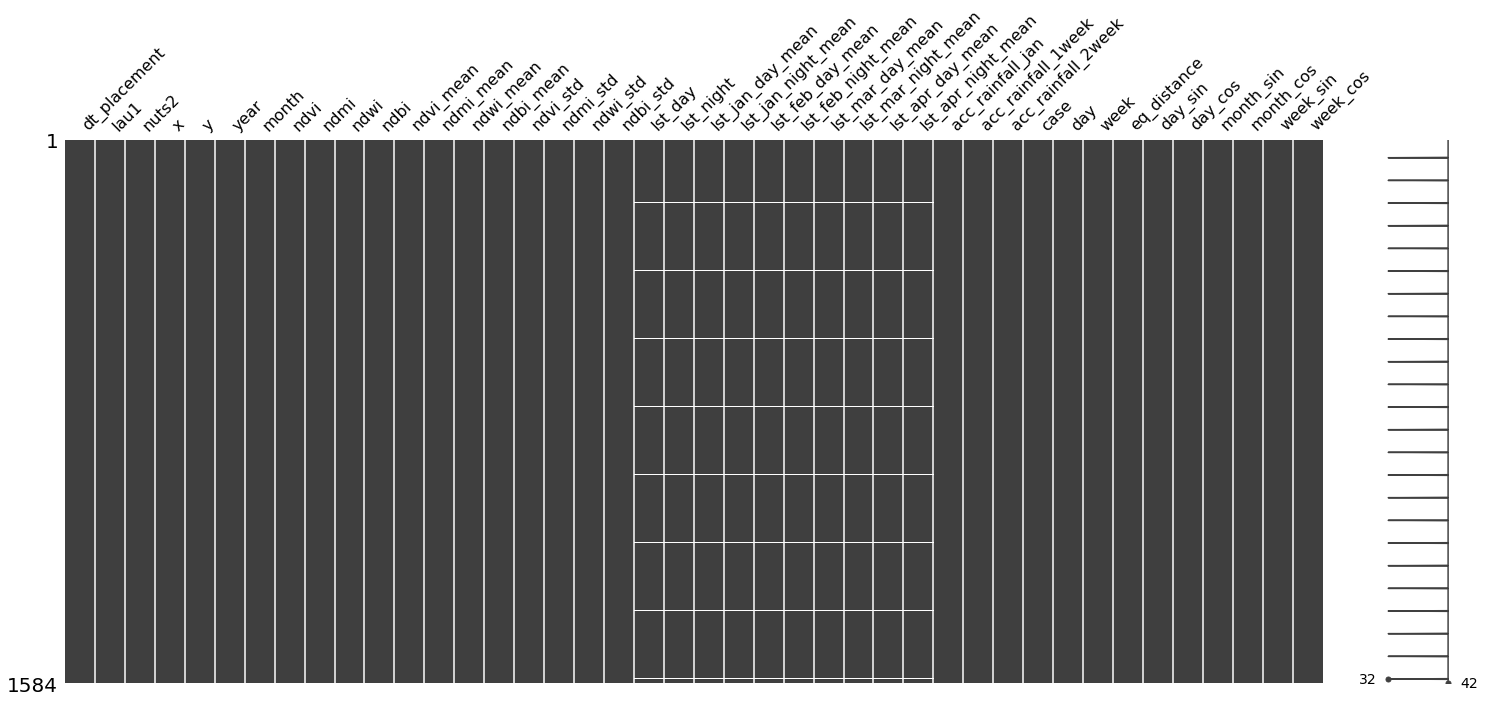

In [58]:
missingno.matrix(dataset)

In [59]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [60]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [61]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [62]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [63]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας βαρβαρας,2.4,10925.9,26759.0
1,αγιας παρασκευης,7.9,7557.5,62157.0
2,αγιου δημητριου,5.0,14402.8,71747.0
3,αγιων αναργυρων καματερου,9.2,6833.8,61427.0
4,αγκιστριου,13.4,85.2,1107.0
...,...,...,...,...
61,φιλοθεης ψυχικου,6.1,4421.0,27400.0
62,φυλης,109.1,421.2,48255.0
63,χαϊδαριου,22.7,2069.6,46983.0
64,χαλανδριου,10.8,6869.6,77118.0


In [64]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['νικαιας αγιου ι. ρεντη', 'πειραιως', 'τροιζηνιας', 'φιλαδελφειας χαλκηδονος']

Length: 4


In [65]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νικαιας αγιου ιωαννη ρεντη', 'νικαιας αγιου ι. ρεντη'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('πειραια', 'πειραιως',))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('τροιζηνιας μεθανων', 'τροιζηνιας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νεας φιλαδελφειας νεας χαλκηδονας','φιλαδελφειας χαλκηδονος'))


In [66]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [67]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

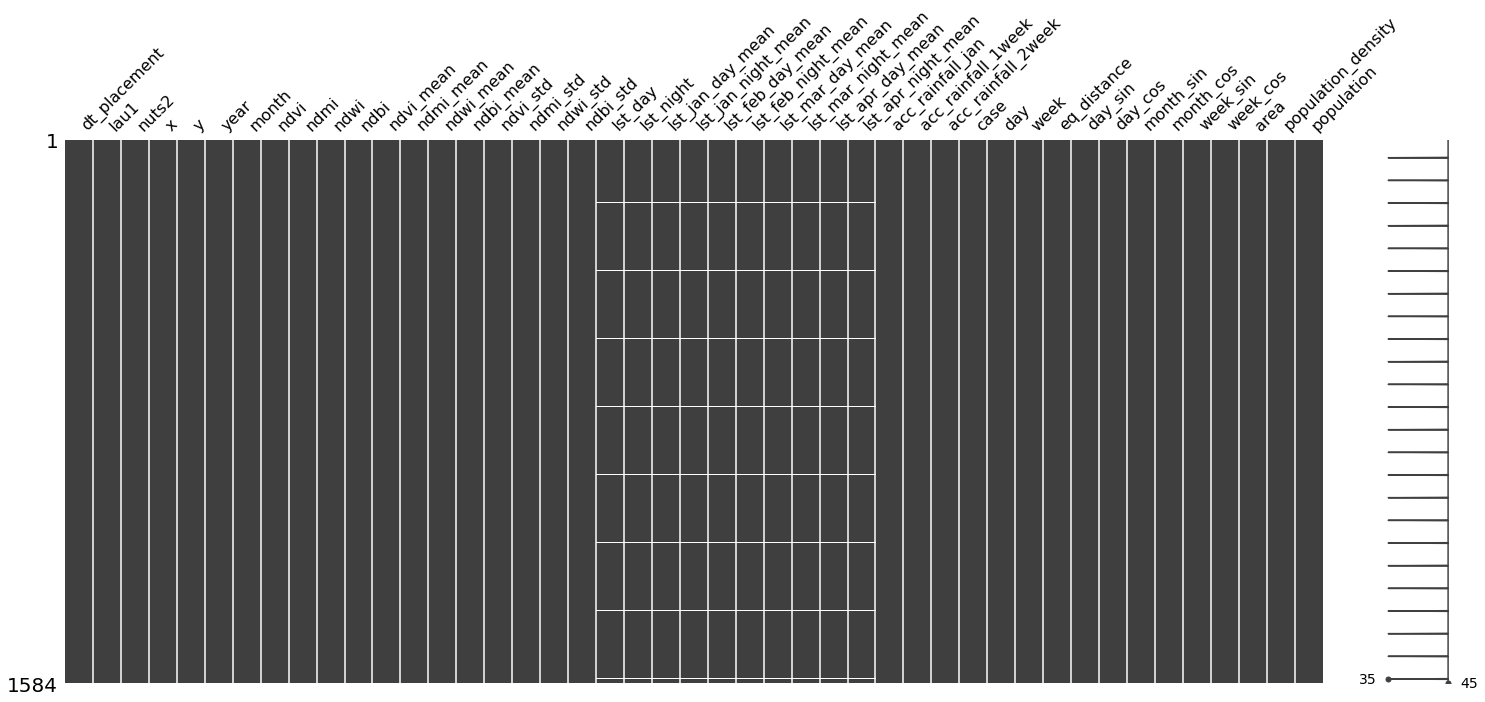

In [68]:
missingno.matrix(dataset)

In [69]:
missing = describe_dataframe(dataset)

In [70]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2022-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022,1,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.000000,14165.000000,14199.125000,13934.842105,14363.375000,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592,0,1,52,44.75555,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,2.4,10925.9,26759.0
1,2022-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2022,1,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.000000,14100.000000,14099.818182,13918.117647,14384.600000,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748,0,1,52,44.85879,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,7.9,7557.5,62157.0
2,2022-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2022,1,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.000000,14139.000000,14200.181818,13948.187500,14414.100000,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617,0,1,52,44.74465,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,5.0,14402.8,71747.0
3,2022-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2022,1,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,14199.000000,14119.000000,14190.625000,13901.705882,14401.750000,13960.200000,14454.111111,13833.666667,15002.235294,14317.058824,0.170459,0.170459,0.170459,0,1,52,44.83209,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,9.2,6833.8,61427.0
4,2022-01-01,αγκιστριου,αττικης,23.34009,37.69503,2022,1,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14439.000000,14284.000000,14257.210526,14079.428571,14341.461538,14109.933333,14310.692308,14083.846154,14608.150000,14369.600000,0.000000,0.000000,0.000000,0,1,52,44.33593,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,13.4,85.2,1107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,2022-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2022,12,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,14388.000000,14246.000000,14126.733333,13924.937500,14387.636364,13976.357143,14458.777778,13907.812500,14918.823529,14314.857143,878.533587,64.381842,66.835793,0,16,50,44.83787,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,6.1,4421.0,27400.0
1580,2022-12-16,φυλης,αττικης,23.68862,38.10670,2022,12,0.216847,0.110849,-0.152700,-0.110849,0.226193,0.088282,-0.180252,-0.088282,0.052931,0.038263,0.061033,0.038263,14316.666667,13979.000000,14073.853817,13832.119048,14245.753302,13860.322611,14232.629759,13766.500000,14818.647475,14186.453276,829.531002,37.073307,38.705631,0,16,50,44.86949,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,109.1,421.2,48255.0
1581,2022-12-16,χαλανδριου,αττικης,23.80941,38.02226,2022,12,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,14403.000000,14164.000000,14091.900000,13949.066667,14388.250000,13990.642857,14367.100000,13856.142857,14917.647059,14351.625000,930.487912,72.550454,75.314096,0,16,50,44.86179,-

In [71]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2022.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2022-01-01,43
1,23.826420,38.008060,2022-01-01,31
2,23.730310,37.933570,2022-01-01,38
3,23.713410,38.047210,2022-01-01,38
4,23.340090,37.695030,2022-01-01,36
...,...,...,...,...
1579,23.776280,38.014770,2022-12-16,1
1580,23.688620,38.106703,2022-12-16,1
1581,23.809410,38.022260,2022-12-16,1
1582,23.630840,38.009420,2022-12-16,1


In [72]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [73]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [74]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0


In [75]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [76]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [77]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [78]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2022-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022,1,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.0,14165.0,14199.125000,13934.842105,14363.375000,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592,0,1,52,44.75555,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,2.4,10925.9,26759.0,43
1,2022-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2022,1,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.0,14100.0,14099.818182,13918.117647,14384.600000,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748,0,1,52,44.85879,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,7.9,7557.5,62157.0,7
2,2022-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2022,1,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.0,14139.0,14200.181818,13948.187500,14414.100000,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617,0,1,52,44.74465,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,5.0,14402.8,71747.0,38
3,2022-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2022,1,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,14199.0,14119.0,14190.625000,13901.705882,14401.750000,13960.200000,14454.111111,13833.666667,15002.235294,14317.058824,0.170459,0.170459,0.170459,0,1,52,44.83209,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,9.2,6833.8,61427.0,39
4,2022-01-01,αγκιστριου,αττικης,23.34009,37.69503,2022,1,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14439.0,14284.0,14257.210526,14079.428571,14341.461538,14109.933333,14310.692308,14083.846154,14608.150000,14369.600000,0.000000,0.000000,0.000000,0,1,52,44.33593,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,13.4,85.2,1107.0,1


<AxesSubplot:>

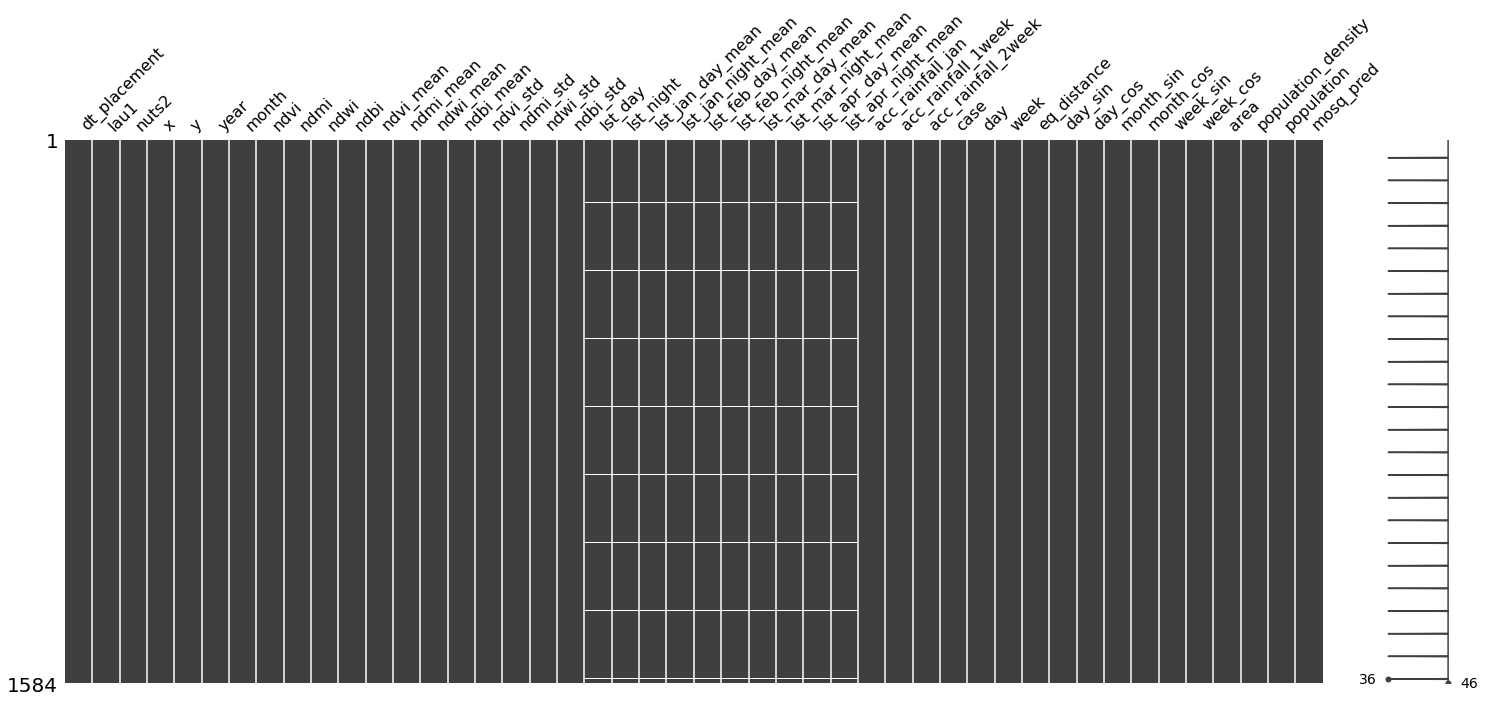

In [79]:
missingno.matrix(dataset)

In [80]:
dataset.reset_index(inplace=True, drop=True)

In [81]:
dataset = calculate_mosq_previous(dataset)

In [82]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

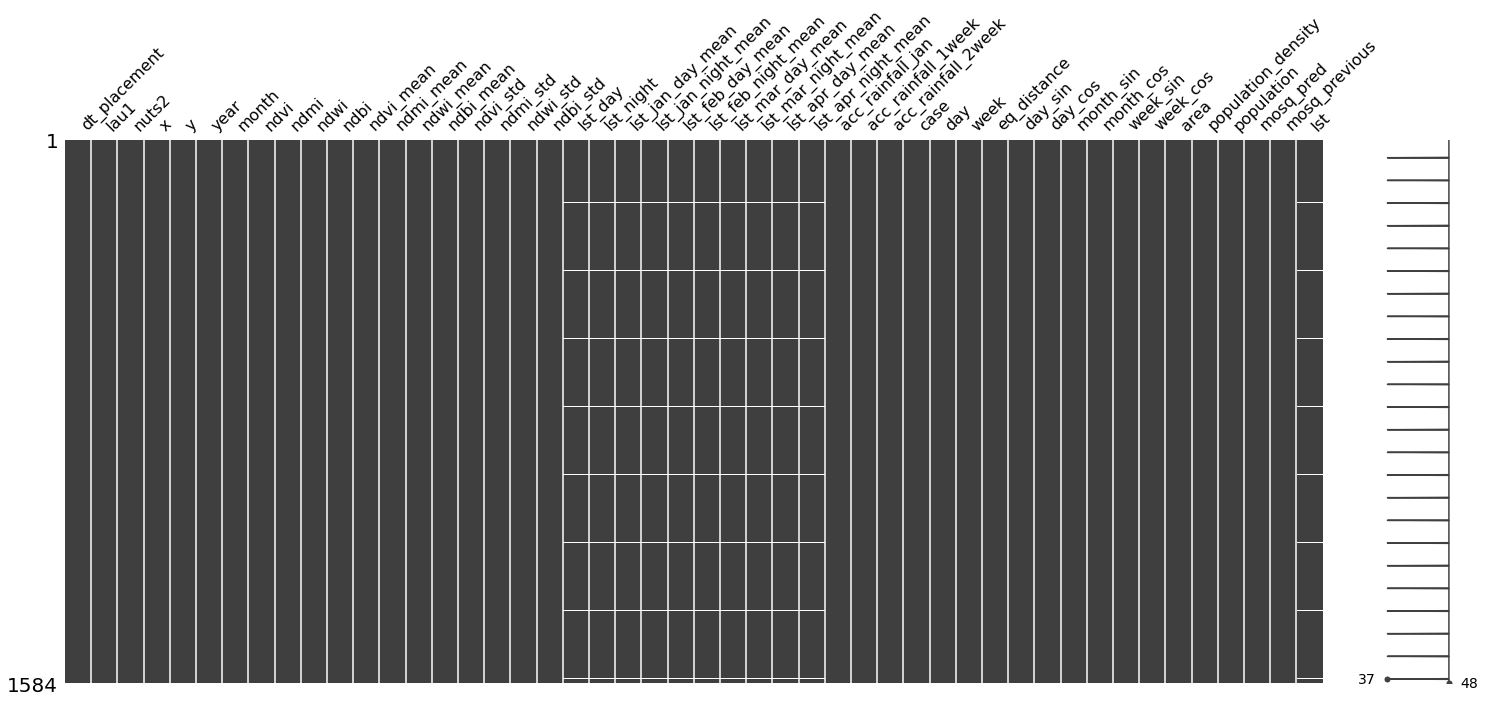

In [83]:
missingno.matrix(dataset)

In [84]:
dataset['case'].value_counts()

0    1584
Name: case, dtype: int64

In [85]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [86]:
dataset = convert_multiple_cases(dataset)

In [87]:
dataset['case'].value_counts()

0    1584
Name: case, dtype: int64

In [88]:
cols = dataset.columns

In [89]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [90]:
len(cols)

48

In [91]:
# check columns

In [92]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [93]:
len(final_columns)

48

In [94]:
dataset_final = dataset[final_columns].copy()

In [95]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2022-01-01,αττικης,αγιας βαρβαρας,1,1,52,2022,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,2.4,26759.0,10925.9,44.75555,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,10.760000,11.370000,10.150000,10.832500,5.546842,14.117500,7.650000,15.820000,4.696667,26.607647,14.388667,0.130592,0.130592,0.130592,43,0,0
1,23.82642,38.00806,2022-01-01,αττικης,αγιας παρασκευης,1,1,52,2022,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,7.9,62157.0,7557.5,44.85879,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,11.060000,13.270000,8.850000,8.846364,5.212353,14.542000,6.439091,14.580909,4.227143,24.649000,13.442000,0.062748,0.062748,0.062748,7,0,0
2,23.73031,37.93357,2022-01-01,αττικης,αγιου δημητριου,1,1,52,2022,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,5.0,71747.0,14402.8,44.74465,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,10.300000,10.970000,9.630000,10.853636,5.813750,15.132000,8.207500,16.894444,5.475333,26.081000,14.275556,0.160617,0.160617,0.160617,38,0,0
3,23.71341,38.04721,2022-01-01,αττικης,αγιων αναργυρων καματερου,1,1,52,2022,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,9.2,61427.0,6833.8,44.83209,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,10.030000,10.830000,9.230000,10.662500,4.884118,14.885000,6.054000,15.932222,3.523333,26.894706,13.191176,0.170459,0.170459,0.170459,39,0,0
4,23.34009,37.69503,2022-01-01,αττικης,αγκιστριου,1,1,52,2022,0.201299,0.979530,5.000000e-01,0.866025,-0.118273,0.992981,13.4,1107.0,85.2,44.33593,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14.080000,15.630000,12.530000,11.994211,8.438571,13.679231,9.048667,13.063846,8.526923,19.013000,14.242000,0.000000,0.000000,0.000000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,23.77628,38.01477,2022-12-16,αττικης,φιλοθεης ψυχικου,16,12,50,2022,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,6.1,27400.0,4421.0,44.83787,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,13.190000,14.610000,11.770000,9.384667,5.348750,14.602727,6.377143,16.025556,5.006250,25.226471,13.147143,64.381842,66.835793,878.533587,37,74,0
1580,23.68862,38.10670,2022-12-16,αττικης,φυλης,16,12,50,2022,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,109.1,48255.0,421.2,44.86949,0.216847,0.110849,-0.152700,-0.110849,0.226193,0.088282,-0.180252,-0.088282,0.052931,0.038263,0.061033,0.038263,9.806667,13.183333,6.430000,8.327076,3.492381,11.765066,4.056452,11.502595,2.180000,23.222949,10.579066,37.073307,38.705631,829.531002,17,34,0
1581,23.80941,38.02226,2022-12-16,αττικης,χαλανδριου,16,12,50,2022,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.348202,0.937420,10.8,77118.0,6869.6,44.86179,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,12.520000,14.910000,10.130000,8.688000,5.831333,14.615000,6.662857,14.192000,3.972857,25.202941,13.882500,72.550454,75.314096,930.487912,29,58,0
1582,23.63084,38.00942,2022-12-

In [96]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv", encoding = enc, index = False)